In [1]:
# Dependencies

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_moons, make_circles, make_classification
from sklearn.metrics import ConfusionMatrixDisplay
import pandas as pd

# Set global DPI for all plots
plt.rcParams['figure.dpi'] = 300

## Let us begin by making a synthetic dataset with two classes

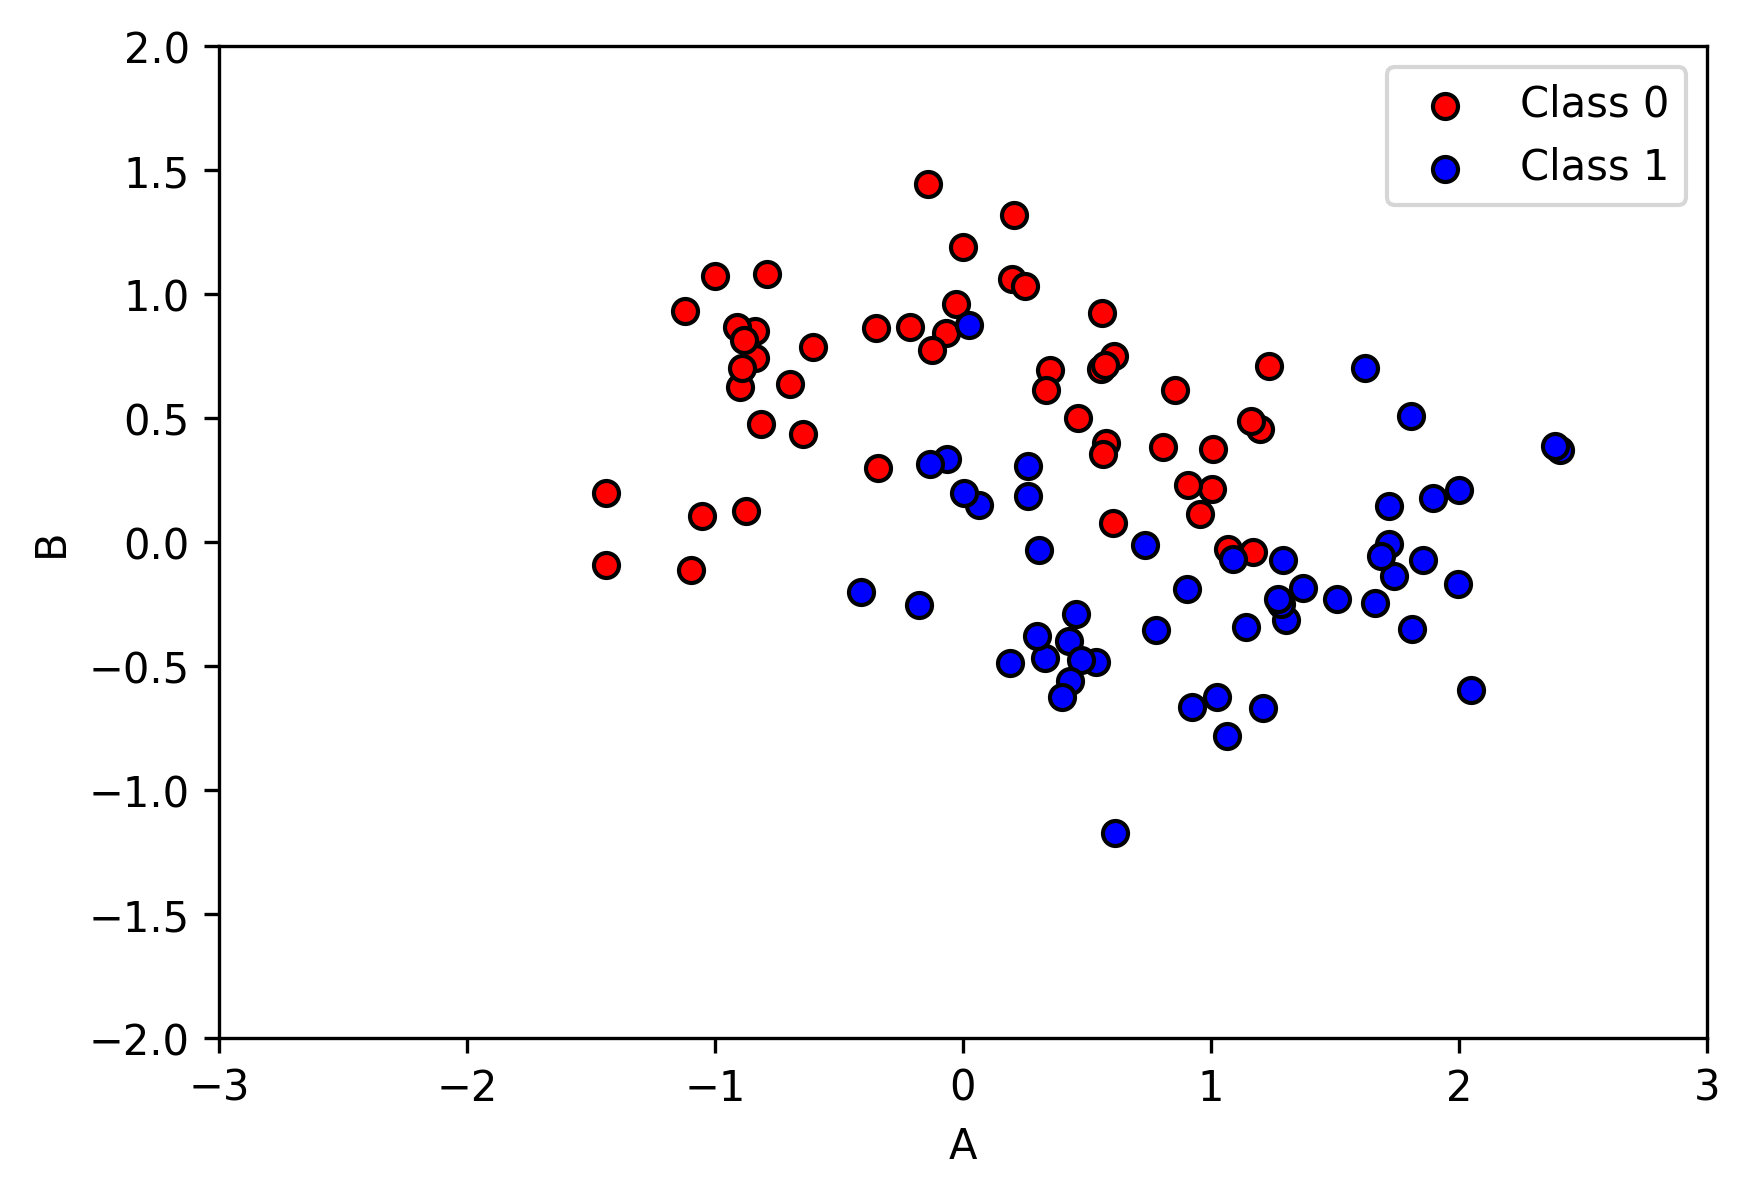

In [2]:
data, labels = make_moons(noise=0.25, random_state=1)

# Let us also plot the data
fig, ax = plt.subplots()

# Plot each class separately for legend
ax.scatter(data[labels == 0, 0], data[labels == 0, 1], c='#FF0000', label='Class 0', edgecolors='k')
ax.scatter(data[labels == 1, 0], data[labels == 1, 1], c='#0000FF', label='Class 1', edgecolors='k')

ax.set_xlabel('A')
ax.set_ylabel('B')
ax.set_xlim([-3,3])
ax.set_ylim([-2,2])
ax.set_aspect('equal')
ax.legend()
plt.show()

## Let us define the training set

First, we split the data into training (60%), validation (20%), and testing (20%) sets.

In [3]:
# Split into train (70%), validation (20%), test (10%) in one step
np.random.seed(0)
indices = np.random.permutation(len(data))

train_end = int(0.7 * len(data))
val_end = int(0.9 * len(data))

train_data = data[indices[:train_end]]
validation_data = data[indices[train_end:val_end]]
test_data = data[indices[val_end:]]

train_labels = labels[indices[:train_end]]
validation_labels = labels[indices[train_end:val_end]]
test_labels = labels[indices[val_end:]]

print(f"Train: {len(train_data)}, Validation: {len(validation_data)}, Test: {len(test_data)}")

Train: 70, Validation: 20, Test: 10


Then, we go ahead and standardize the data. Critically, we want to "fit" scaling to the training set *only*. 

*Why might that be?*

In [4]:
# Figure out the scaling transform using ONLY the training data
scaler = StandardScaler()
scaler.fit(train_data)

# Apply the transform to ALL data
train_data = scaler.transform(train_data)
validation_data = scaler.transform(validation_data)
test_data = scaler.transform(test_data)

## Now, let us apply a *k nearest neighbor classifier*

kNN is a "lazy learner" that stores the entire dataset in memory and for every new (unseen) point:

1. Computes the distance to all training points.
2. Finds *k* nearest neighbors.
3. Assigns the class by majority vote among those neighbors.

Validation Accuracy: 0.900



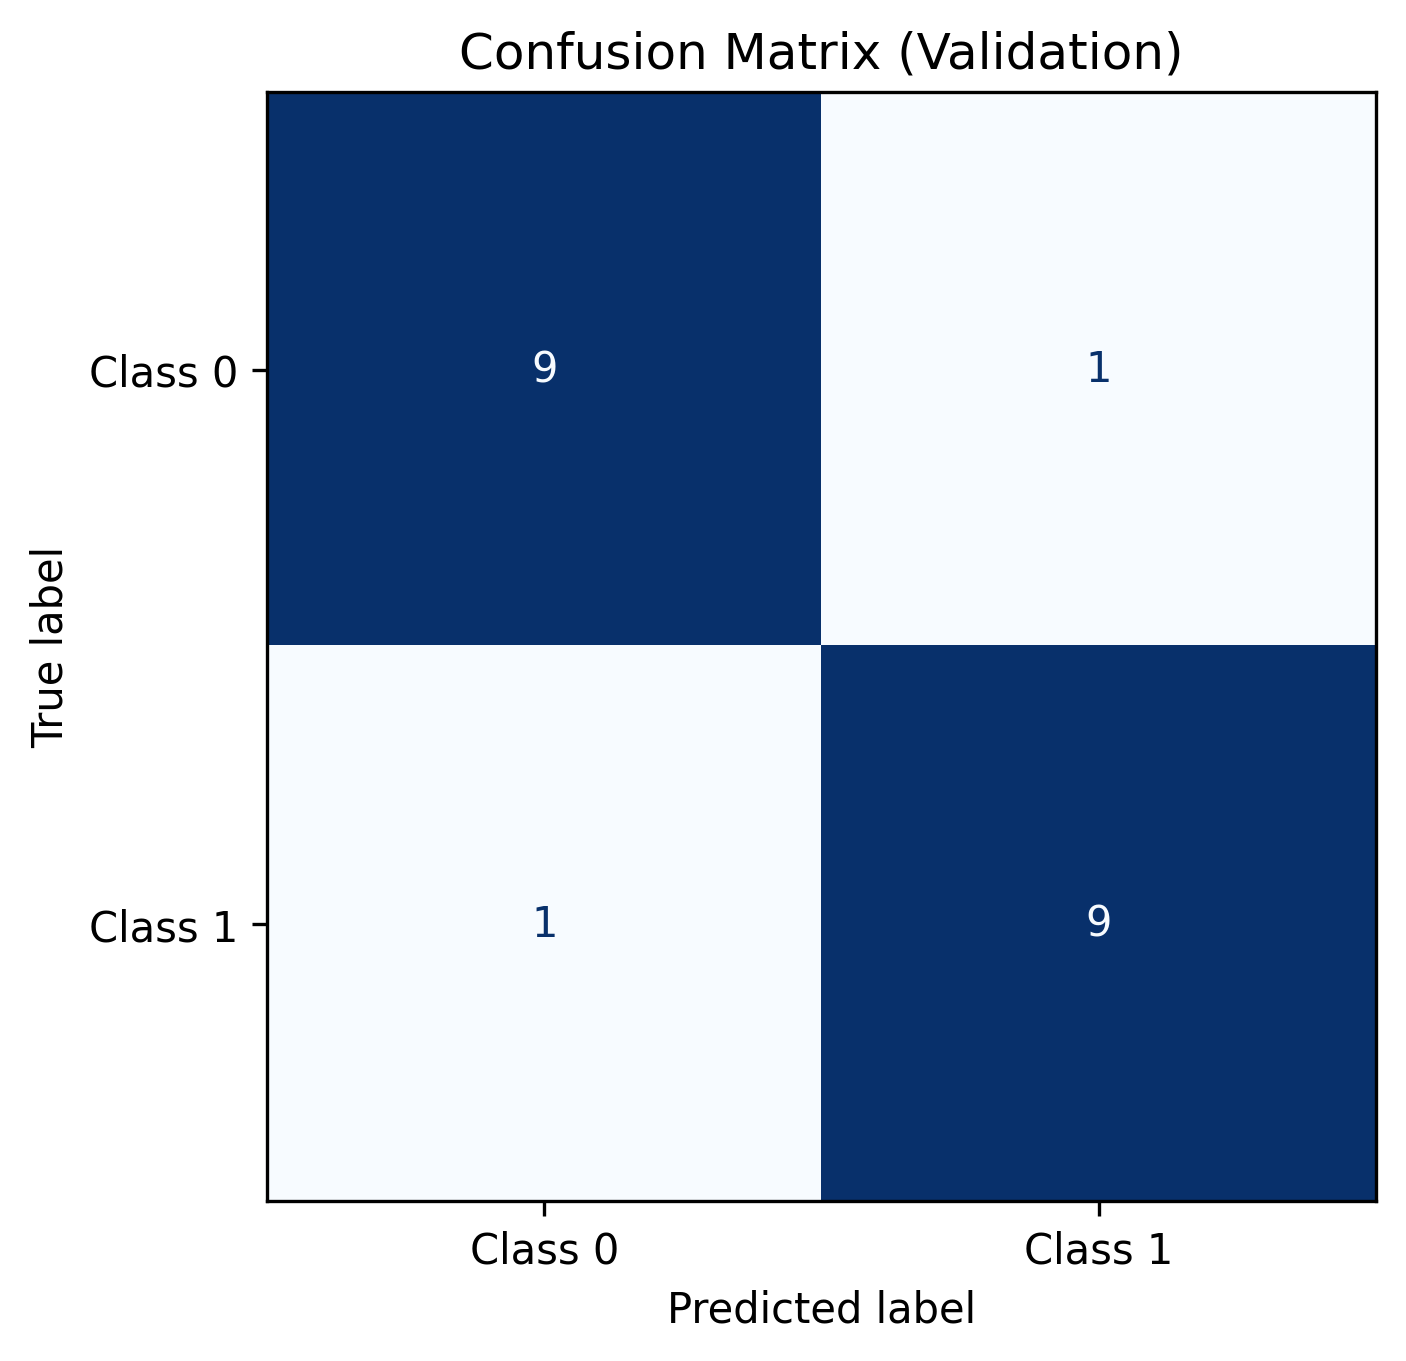


Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.90      0.90        10
           1       0.90      0.90      0.90        10

    accuracy                           0.90        20
   macro avg       0.90      0.90      0.90        20
weighted avg       0.90      0.90      0.90        20



In [5]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

# Create the KNN classifier (k=5 neighbors)
knn = KNeighborsClassifier(n_neighbors=5)

# Train the classifier on the training data
knn.fit(train_data, train_labels)

# Predict on the validation set
validation_pred = knn.predict(validation_data)

# Evaluate performance on validation set
val_accuracy = accuracy_score(validation_labels, validation_pred)
print(f"Validation Accuracy: {val_accuracy:.3f}\n")

# Create and display confusion matrix
cm = confusion_matrix(validation_labels, validation_pred)
fig, ax = plt.subplots()
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix (Validation)')
plt.show()

print("\nClassification Report:")
print(classification_report(validation_labels, validation_pred))

Use the validation data to determine your ideal value for $k$.

Then, apply the model to your test set.

Test Accuracy: 1.000



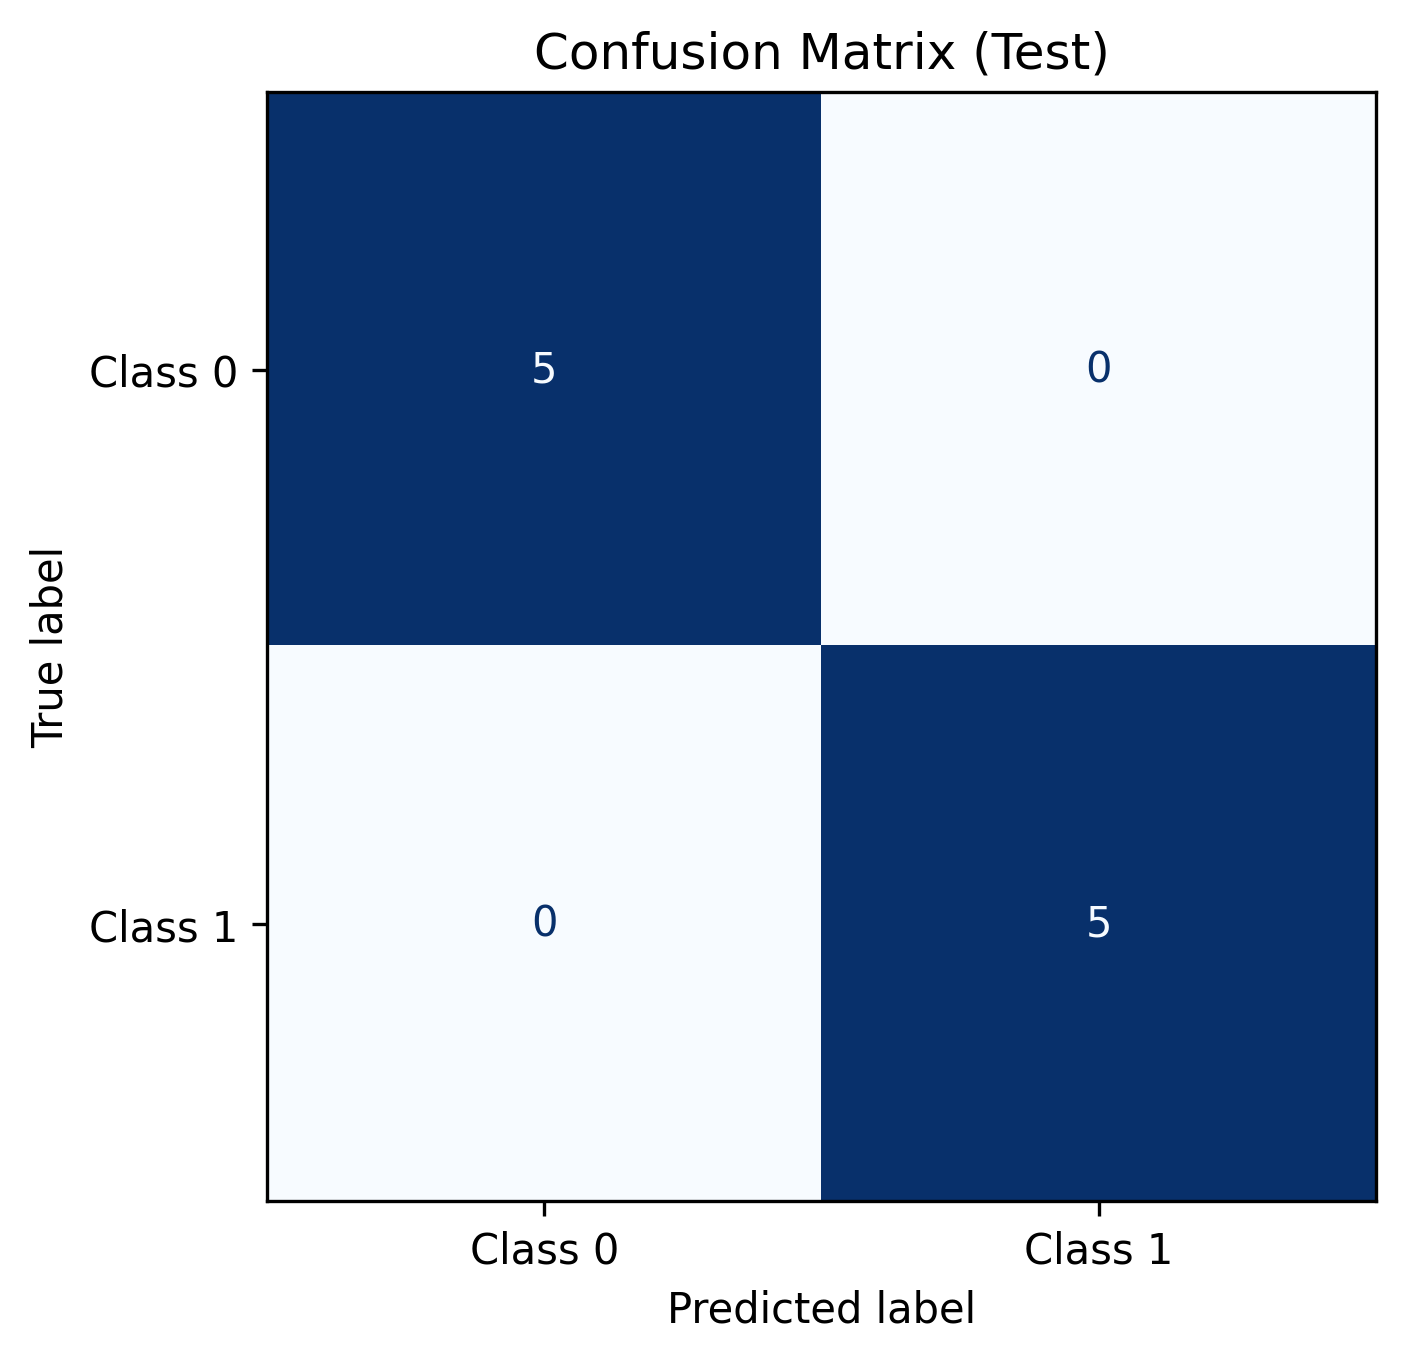


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00         5

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



In [6]:
# Apply the trained kNN model to the test set
test_pred = knn.predict(test_data)

# Evaluate performance on test set
test_accuracy = accuracy_score(test_labels, test_pred)
print(f"Test Accuracy: {test_accuracy:.3f}\n")

# Create and display confusion matrix
cm = confusion_matrix(test_labels, test_pred)
fig, ax = plt.subplots()
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix (Test)')
plt.show()

print("\nClassification Report:")
print(classification_report(test_labels, test_pred))

## Let us visualize our kNN classifier

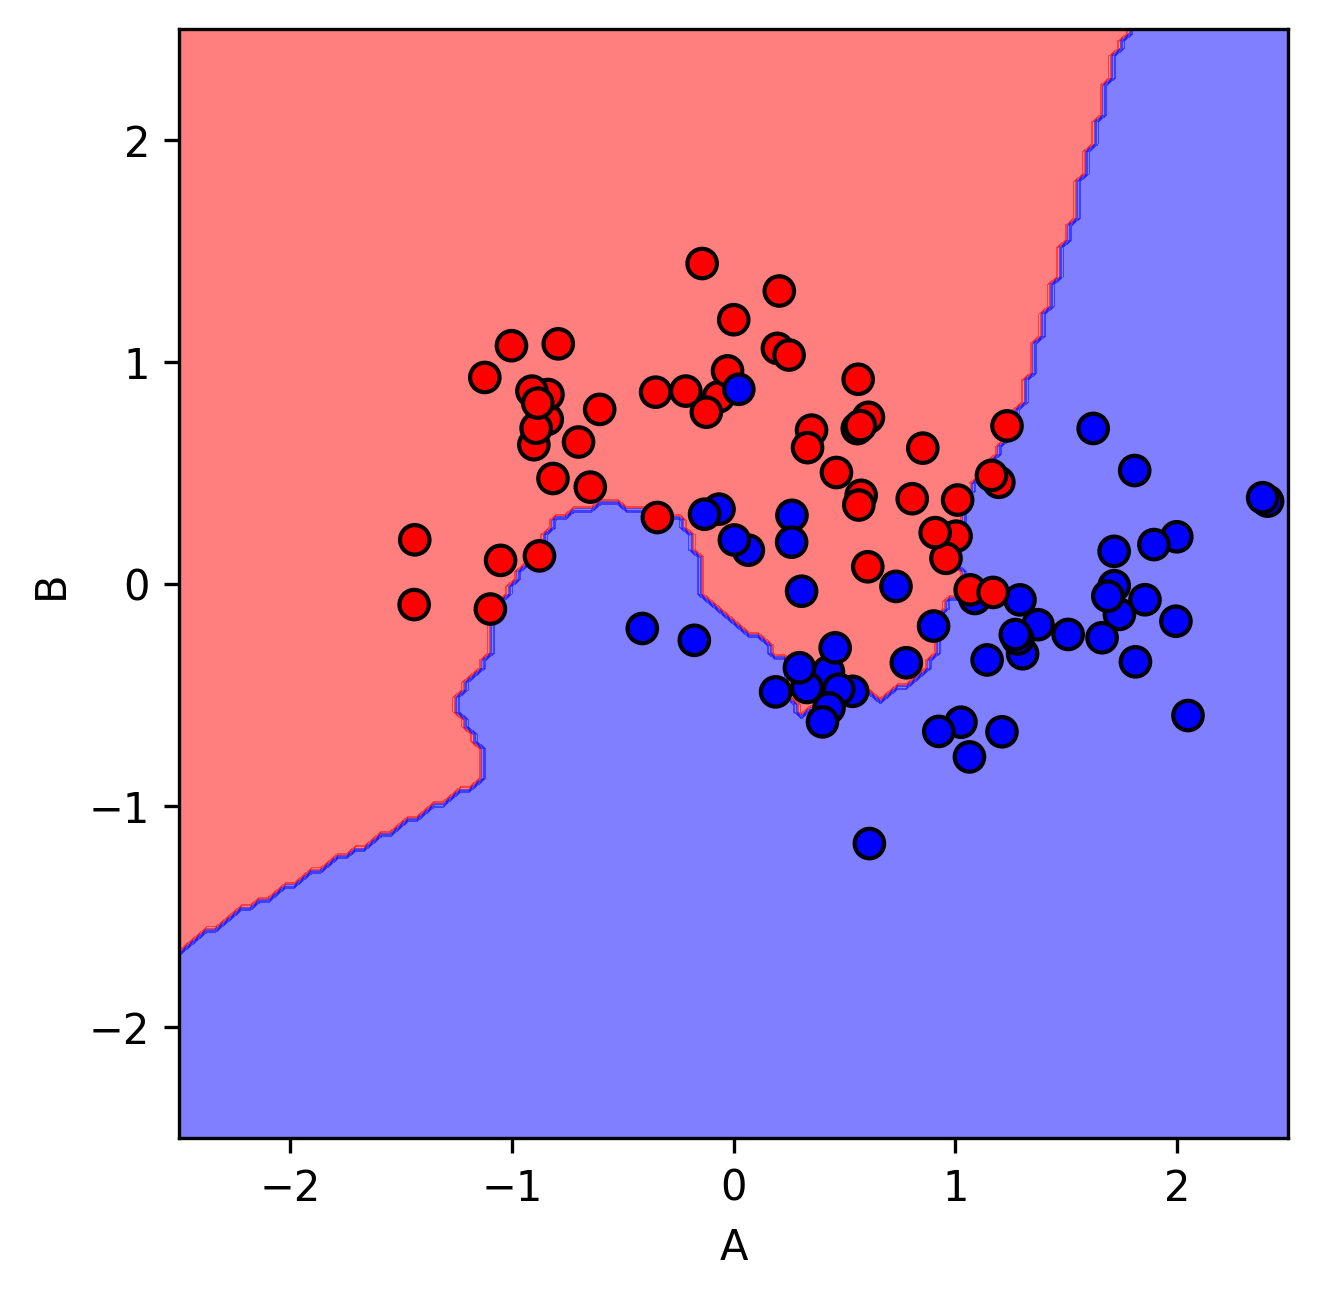

In [7]:
from sklearn.inspection import DecisionBoundaryDisplay

fig, ax = plt.subplots()

# Create decision boundary
DecisionBoundaryDisplay.from_estimator(
    knn, 
    data, 
    cmap=ListedColormap(['#FF0000', '#0000FF']), 
    eps=2,
    alpha=0.5, 
    ax=ax,
    grid_resolution=200,
    response_method='predict'
)

# Plot data points
ax.scatter(data[:, 0], data[:, 1], c=labels, 
           cmap=ListedColormap(['#FF0000', '#0000FF']), edgecolors='k', s=50)
ax.set_xlabel('A')
ax.set_ylabel('B')
ax.set_aspect('equal')
ax.set_xlim([-2.5,2.5])
ax.set_ylim([-2.5,2.5])
plt.show()

## Now, let us assemble a ROC using a different classifier

You might notice that kNN is based on a majority decision.

Some classifiers provide prediction probabilities (P) that, when thresholded (typically set at 50%), determine the class of an input.

So, in such a case, we would say that something is positive if $ P \ge .50$.

One thing we might want to do is test how TPR ($\frac{TP}{TP + FN}$) and FPR ($\frac{FP}{FP + TN}$) change as our choice of threshold changes. To do so, we will generate a ROC curve.


### Naive Bayes Classifier

**Naive Bayes** (NB) is a probabilistic classifier based on Bayes' theorem:

$$P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B)}$$

To classify a new sample, we compute the probability of each class given the features and pick the most probable class.

The "naive" part of NB is the assumption that features are **conditionally independent** given the class. That is, the information one variable tells us about the class is unrelated to information from other variables.

### Training a NB classifier

Training a NB involved computing statistics of your training set.

1. **Class priors** $P(y)$: Count the proportion of each class in the training data.

2. **Feature likelihoods** $P(x_i|y)$: For continuous features (Gaussian Naive Bayes), estimate the mean and variance of each feature for each class. Then use the Gaussian probability density function:

$$P(x_i|y) = \frac{1}{\sqrt{2\pi\sigma_{i,y}^2}} \exp\left(-\frac{(x_i - \mu_{i,y})^2}{2\sigma_{i,y}^2}\right)$$

where $\mu_{i,y}$ is the mean of feature $i$ for class $y$, and $\sigma_{i,y}$ is the standard deviation.

In [8]:
from sklearn.naive_bayes import GaussianNB

# Train a Gaussian Naive Bayes classifier
nb = GaussianNB()
nb.fit(train_data, train_labels)

GaussianNB()

In [9]:
# Combine validation and test data
eval_data = np.vstack([validation_data, test_data])
eval_labels = np.hstack([validation_labels, test_labels])

# Apply our trained model
eval_pred_nb = nb.predict(eval_data)
eval_probs_nb = nb.predict_proba(eval_data)

# Create a formatted DataFrame
eval_df = pd.DataFrame({
    'True Label': eval_labels,
    'Predicted': eval_pred_nb,
    'P(y=0)': eval_probs_nb[:, 0],
    'P(y=1)': eval_probs_nb[:, 1]
})

print("Predictions with Probabilities (Validation + Test):")
display(eval_df)

eval_accuracy_nb = accuracy_score(eval_labels, eval_pred_nb)
print(f"\nAccuracy: {eval_accuracy_nb:.3f}")

Predictions with Probabilities (Validation + Test):


,True Label,Predicted,P(y=0),P(y=1)
0,0,0,0.923910,0.076090
1,0,0,0.997480,0.002520
2,1,0,0.580457,0.419543
3,1,1,0.000240,0.999760
4,0,0,0.752993,0.247007
5,1,1,0.006321,0.993679
6,0,1,0.216497,0.783503
7,0,1,0.413741,0.586259
8,1,1,0.021030,0.978970
9,1,1,0.002321,0.997679



Accuracy: 0.767


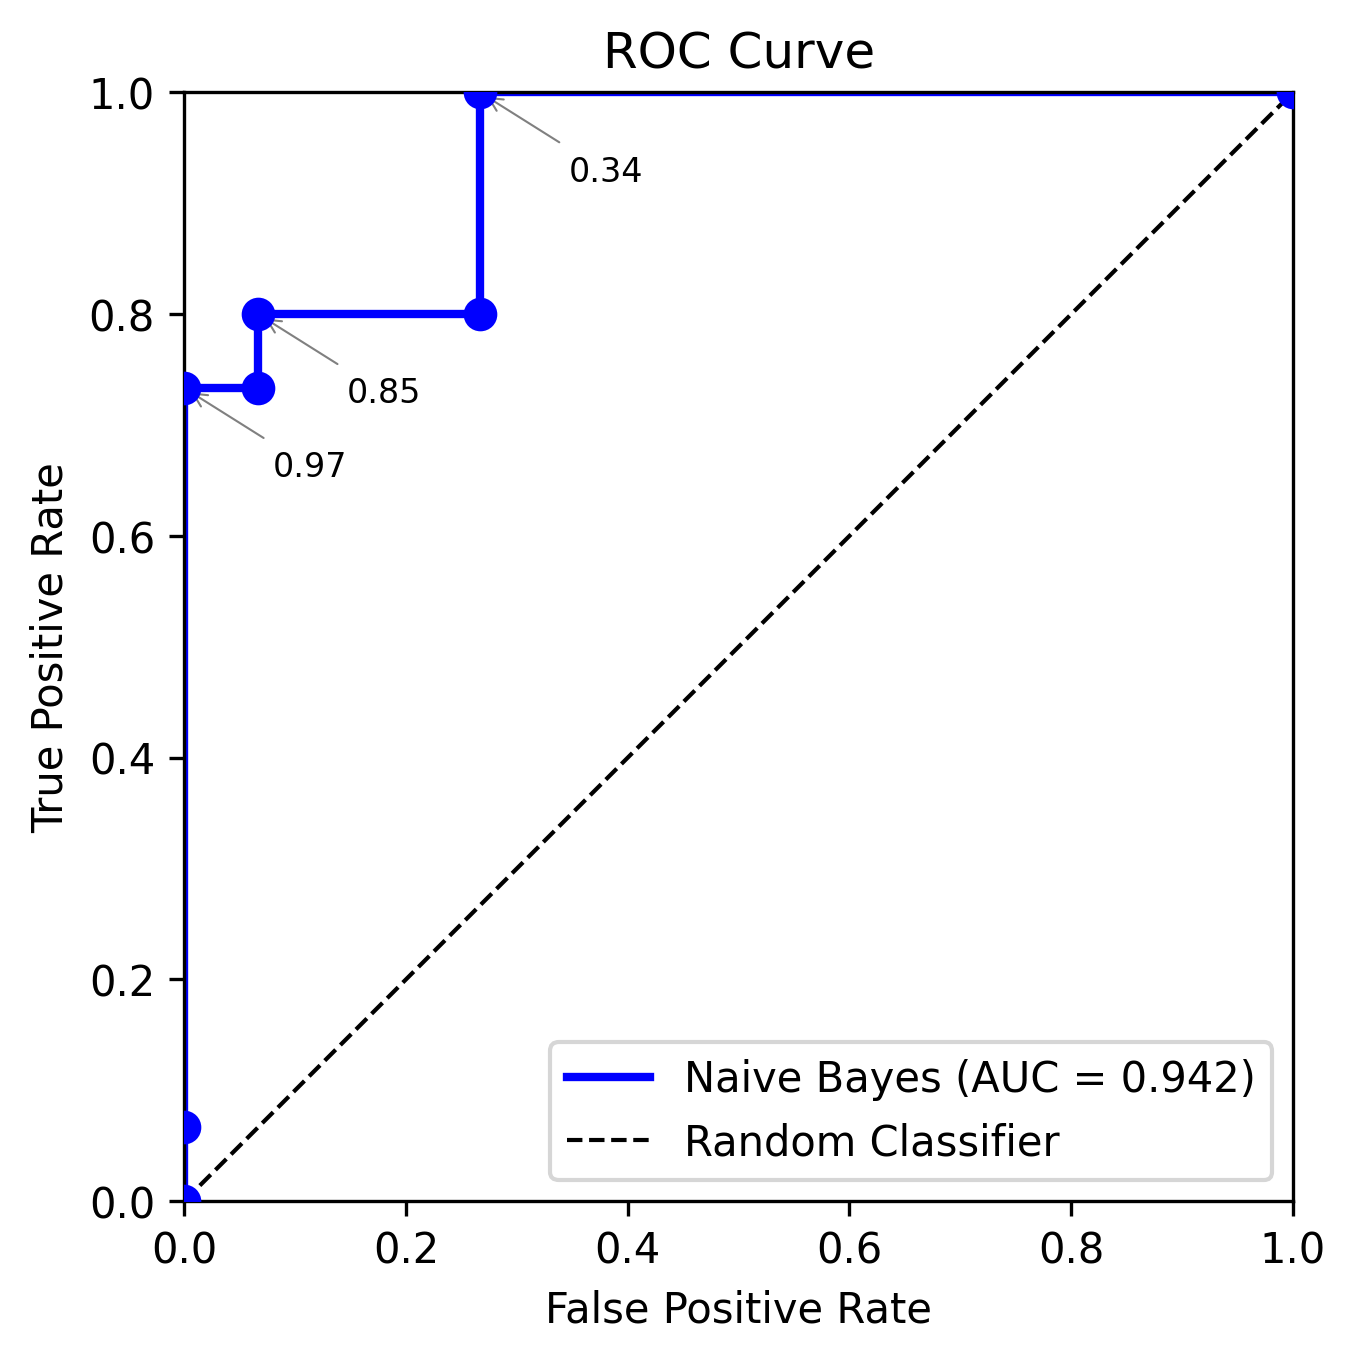

In [10]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get probabilities for the positive class (class 1)
y_probs = eval_probs_nb[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(eval_labels, y_probs)

# Compute AUC
auc = roc_auc_score(eval_labels, y_probs)

# Plot ROC curve
fig, ax = plt.subplots()
ax.plot(fpr, tpr, 'b-', linewidth=2, label=f'Naive Bayes (AUC = {auc:.3f})')
ax.scatter(fpr, tpr, c='blue', s=50, zorder=5)

# Label every other point, skip inf, with arrow pointing to point
for i, thresh in enumerate(thresholds):
    if i % 2 == 0 and not np.isinf(thresh):
        ax.annotate(f'{thresh:.2f}', 
                    xy=(fpr[i], tpr[i]),
                    xytext=(fpr[i] + 0.08, tpr[i] - 0.08),
                    fontsize=8,
                    arrowprops=dict(arrowstyle='->', color='gray', lw=0.5))

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend(loc='lower right')
ax.set_aspect('equal')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
plt.show()

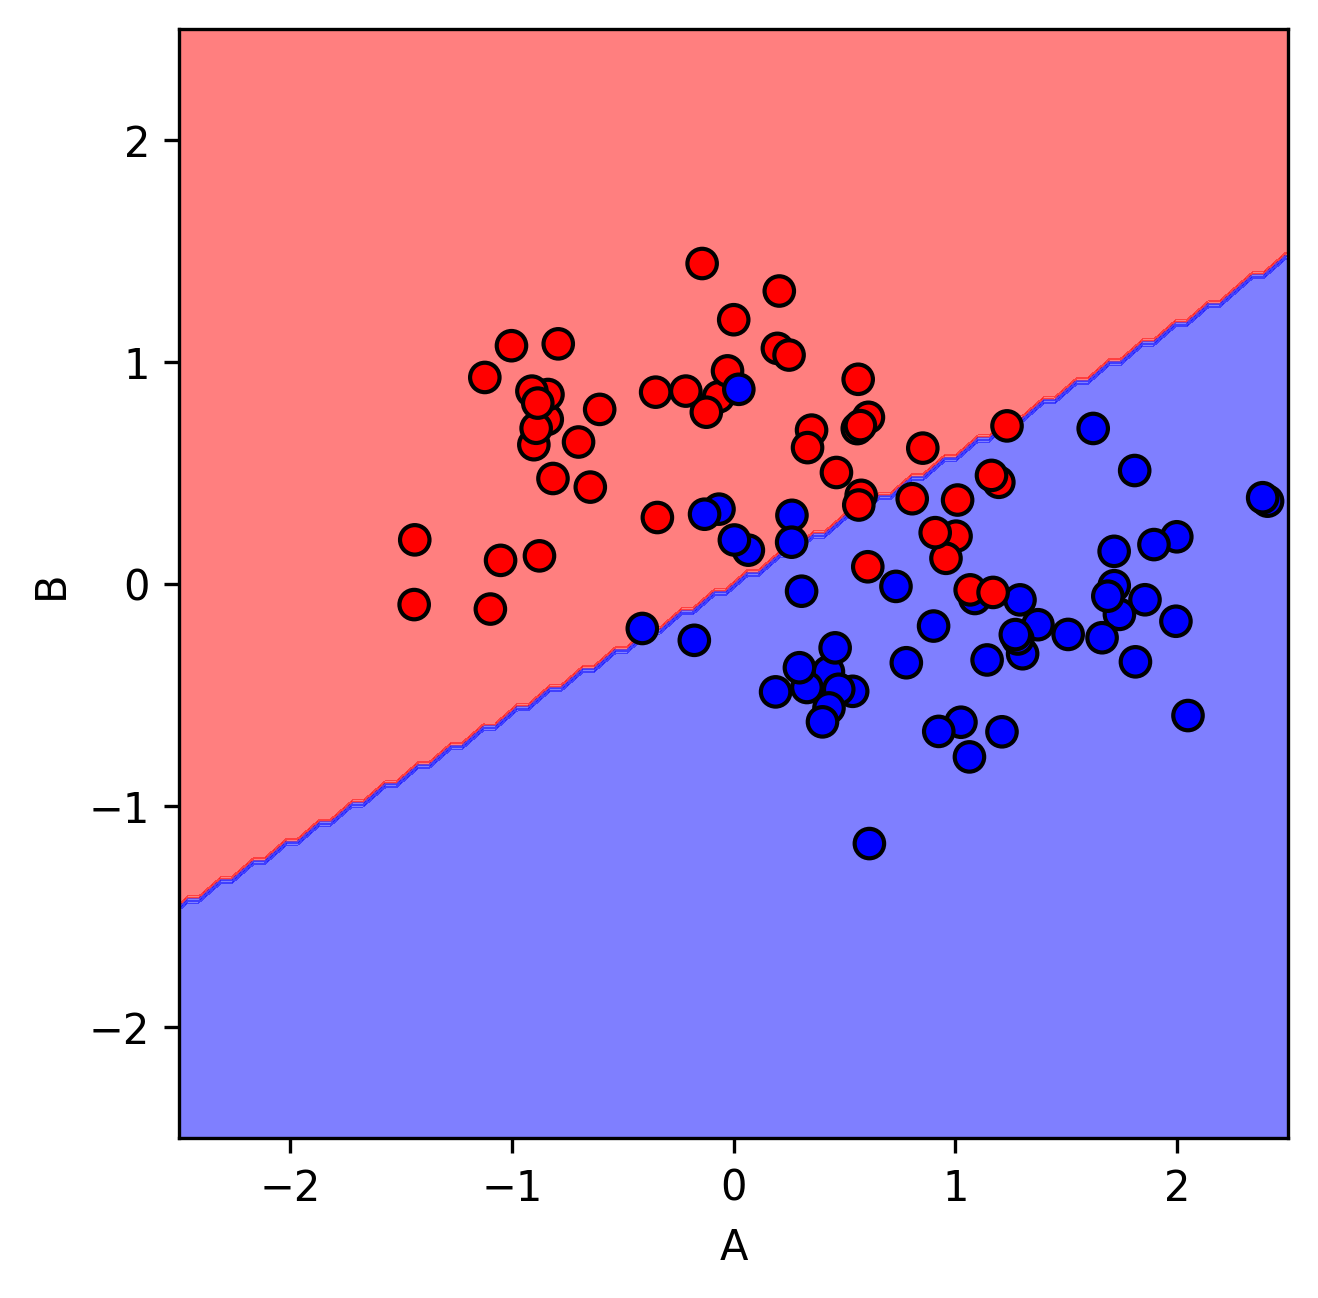

In [11]:
from sklearn.inspection import DecisionBoundaryDisplay

fig, ax = plt.subplots()

# Create decision boundary for Naive Bayes
DecisionBoundaryDisplay.from_estimator(
    nb, 
    data, 
    cmap=ListedColormap(['#FF0000', '#0000FF']), 
    alpha=0.5, 
    ax=ax,
    eps=3,
    grid_resolution=200,
    response_method='predict'
)

# Plot training points
ax.scatter(data[:, 0], data[:, 1], c=labels, 
           cmap=ListedColormap(['#FF0000', '#0000FF']), edgecolors='k', s=50)
ax.set_xlabel('A')
ax.set_ylabel('B')
ax.set_aspect('equal')
ax.set_xlim([-2.5, 2.5])
ax.set_ylim([-2.5, 2.5])
plt.show()

## Decision Tree Classifier

A **decision tree** is a flowchart-like structure that makes predictions by splitting data based on feature values. At each node, the tree asks a yes/no question about a feature (e.g., "Is $x_1 > 0.5$?") and branches accordingly.

For classification, each leaf node contains training samples. The predicted **probability** is simply the proportion of each class in that leaf. For example, if a leaf has 8 positive and 2 negative samples, $P(y=1) = 0.8$.

### Training a Decision Tree

A decision tree is built by recursively finding the best feature and threshold to split the data. At each step, we want splits that make the resulting groups as **homogeneous** as possible (i.e., containing mostly one class).

A common measure of impurity is the **Gini impurity**:

$$Gini = 1 - \sum_{k=1}^{K} p_k^2$$

where $p_k$ is the proportion of class $k$ in a node. A homogeneous node (all one class) has $Gini = 0$.

The algorithm greedily selects the split that minimizes the Gini of the child nodes, continuing until a stopping criterion is met (e.g., max depth, min samples per leaf).

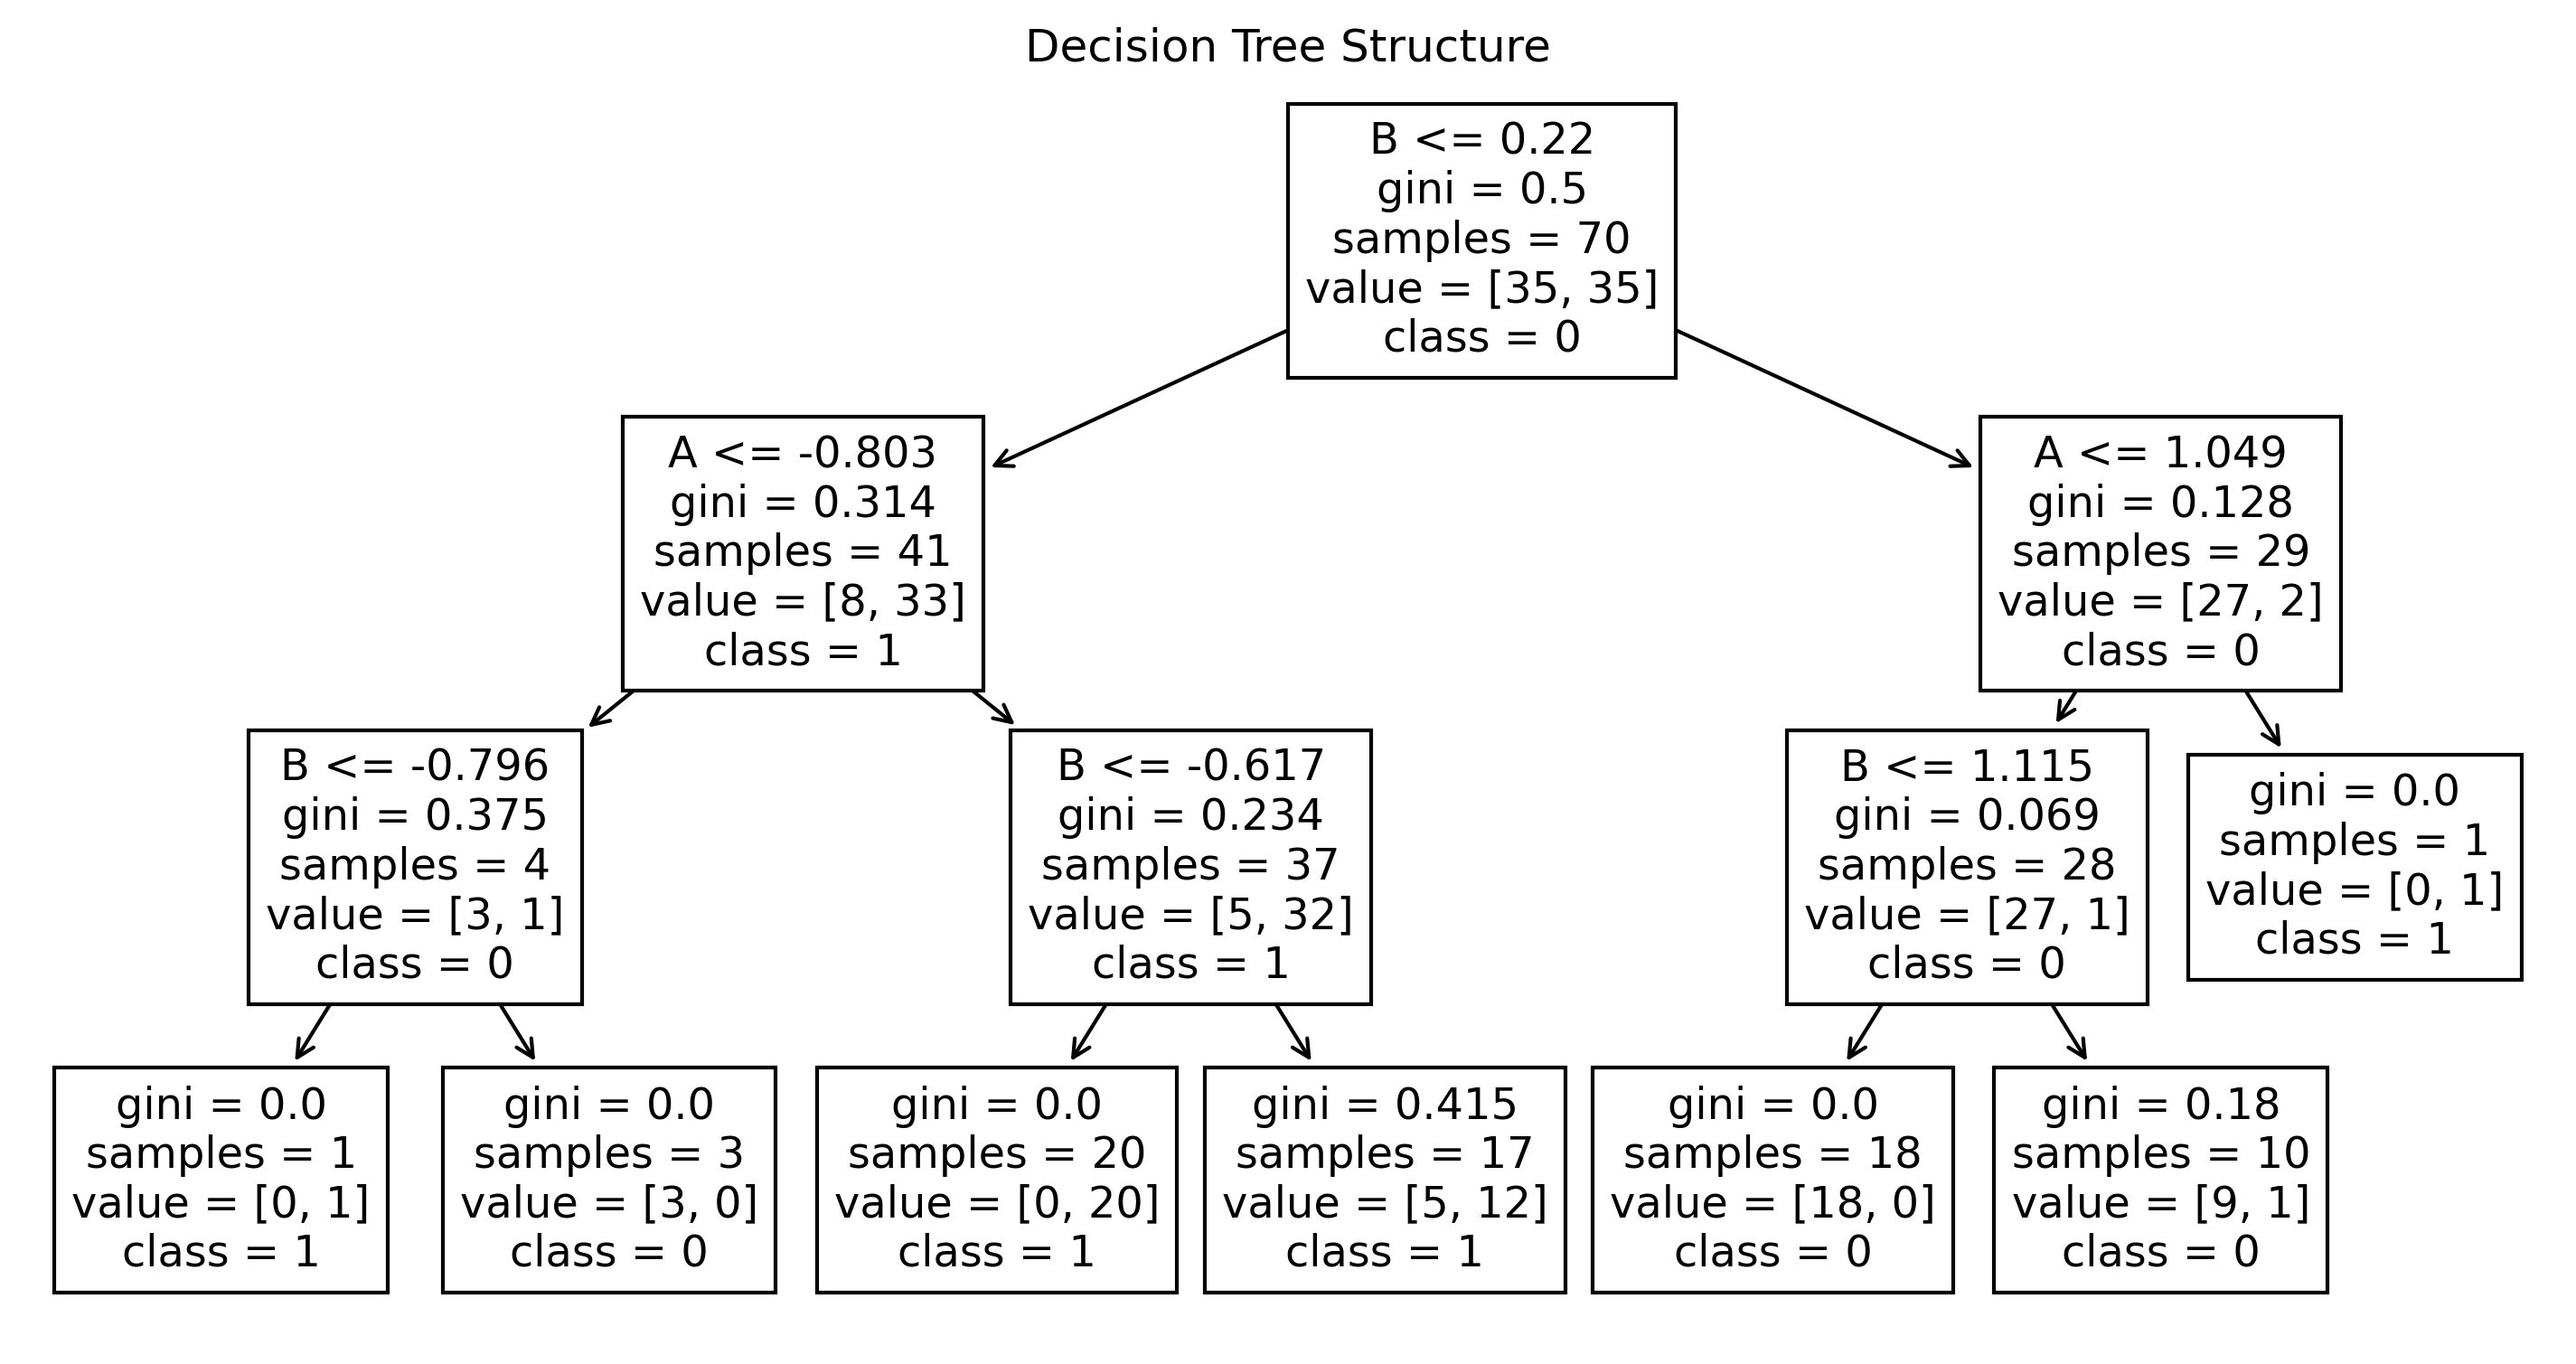

In [12]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Train a simple decision tree for visualization
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(train_data, train_labels)

# Visualize the tree
fig, ax = plt.subplots(figsize=(12, 6))
plot_tree(dt, feature_names=['A', 'B'], 
          class_names=['0', '1'], filled=False, rounded=False, ax=ax)
plt.title('Decision Tree Structure')
plt.show()

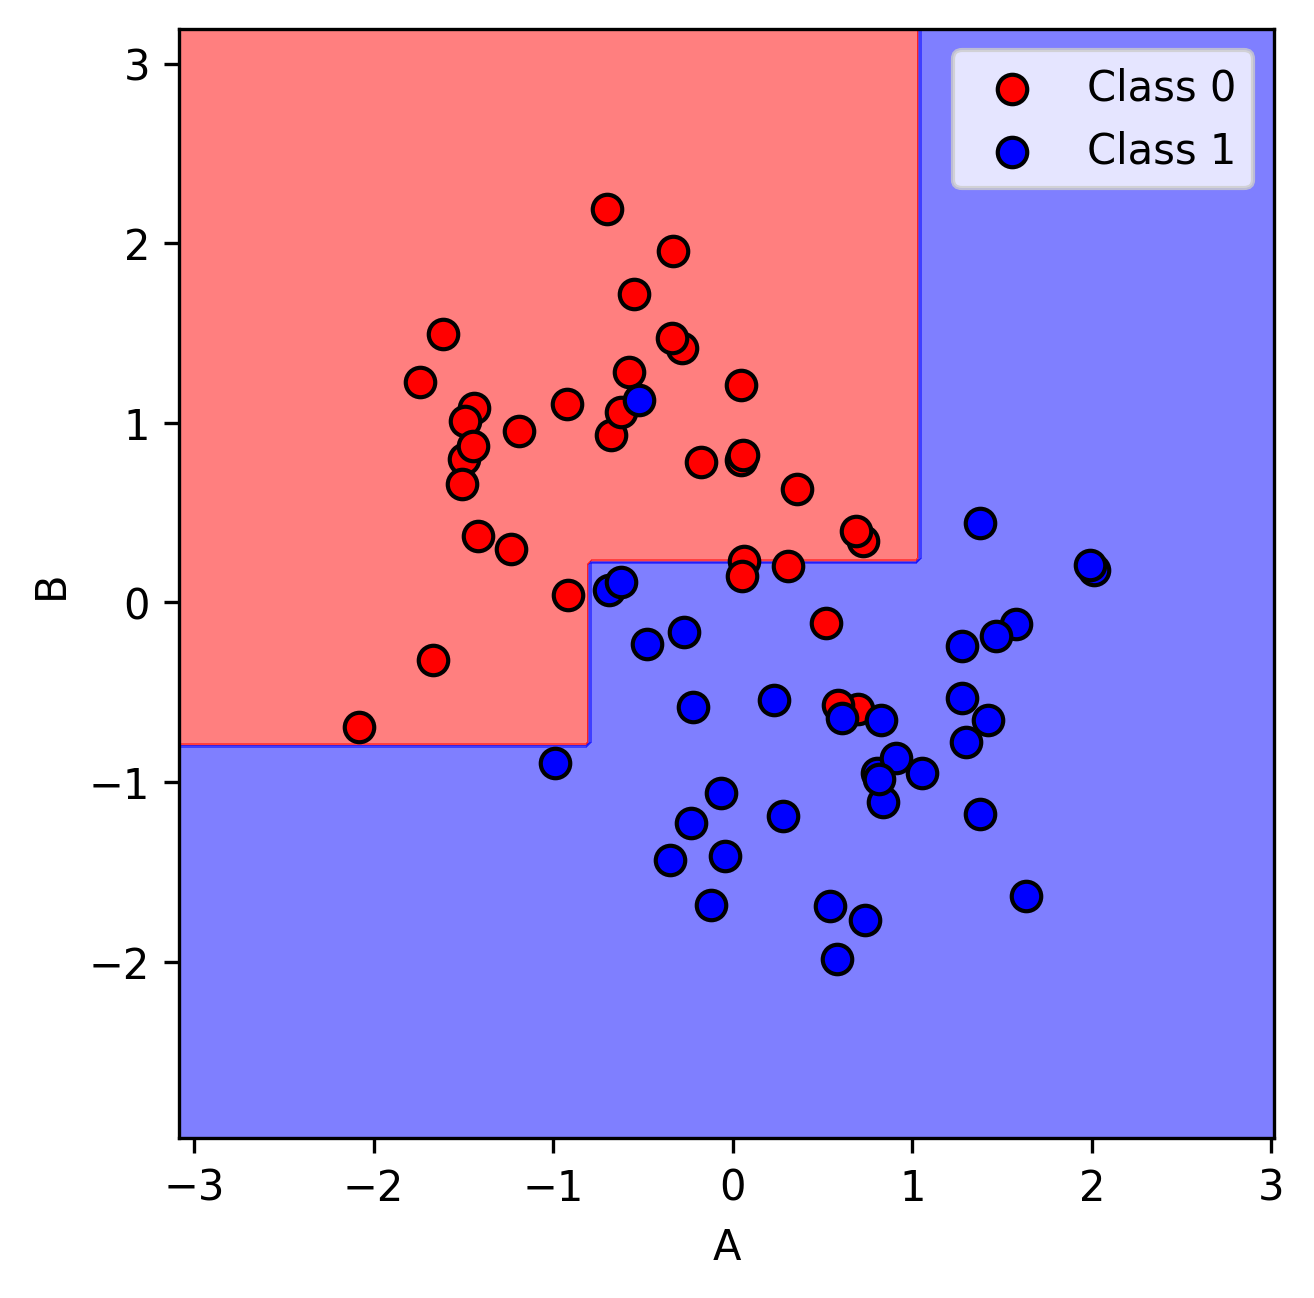

In [13]:
fig, ax = plt.subplots()

# Create decision boundary for Decision Tree
DecisionBoundaryDisplay.from_estimator(
    dt, 
    train_data, 
    cmap=ListedColormap(['#FF0000', '#0000FF']), 
    alpha=0.5, 
    ax=ax,
    grid_resolution=200,
    response_method='predict'
)

# Plot training points
ax.scatter(train_data[train_labels == 0, 0], train_data[train_labels == 0, 1], 
           c='#FF0000', label='Class 0', edgecolors='k', s=50)
ax.scatter(train_data[train_labels == 1, 0], train_data[train_labels == 1, 1], 
           c='#0000FF', label='Class 1', edgecolors='k', s=50)
ax.set_xlabel('A')
ax.set_ylabel('B')
ax.set_aspect('equal')
ax.legend()
plt.show()